In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_excel(r"E:\DATA sCIENCE\Data set\glass.xlsx")
df

,Prepare a model for glass classification using Random Forest
0,Data Description:
1,RI : refractive index
2,Na: Sodium (unit measurement: weight percent i...
3,Mg: Magnesium
4,AI: Aluminum
5,Si: Silicon
6,K:Potassium
7,Ca: Calcium
8,Ba: Barium
9,Fe: Iron


In [58]:
xls = pd.ExcelFile(r"E:\DATA sCIENCE\Data set\glass.xlsx")
xls.sheet_names

['Description', 'glass']

In [59]:
df = pd.read_excel(xls, sheet_name='glass')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [61]:
df.shape

(214, 10)

1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

In [62]:
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [63]:
df.duplicated().sum()

np.int64(1)

In [64]:
df = df.drop_duplicates()

In [65]:
df.shape

(213, 10)

In [66]:
df['Type'].value_counts()

Type
2    76
1    69
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [67]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.


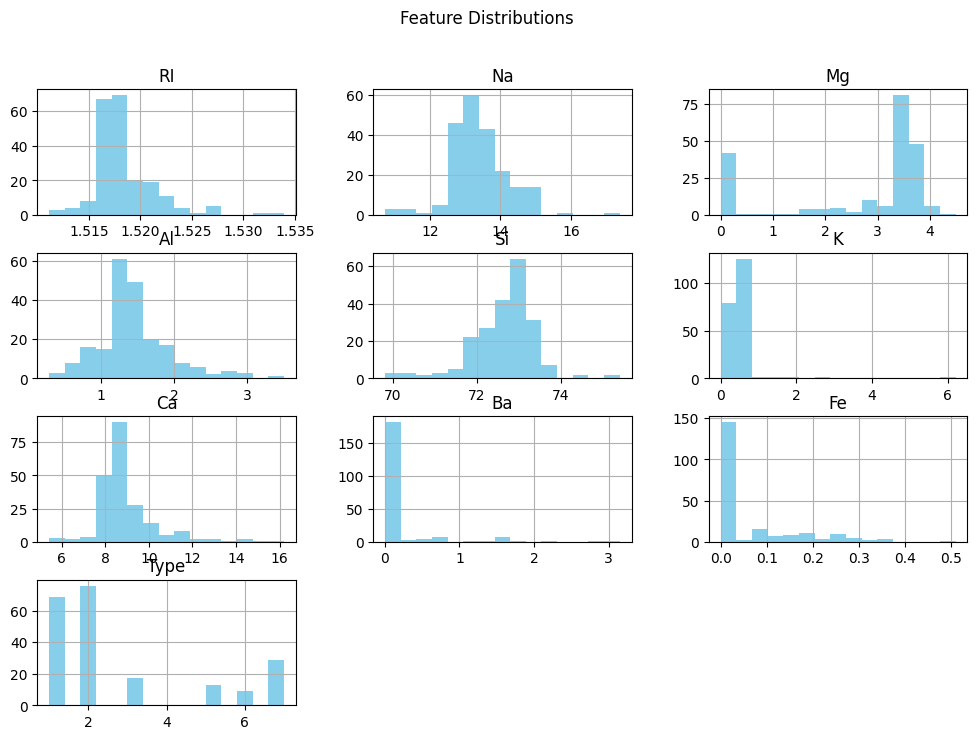

In [26]:
df.hist(figsize=(12,8), bins=15, color='skyblue')
plt.suptitle('Feature Distributions')
plt.show()


[]

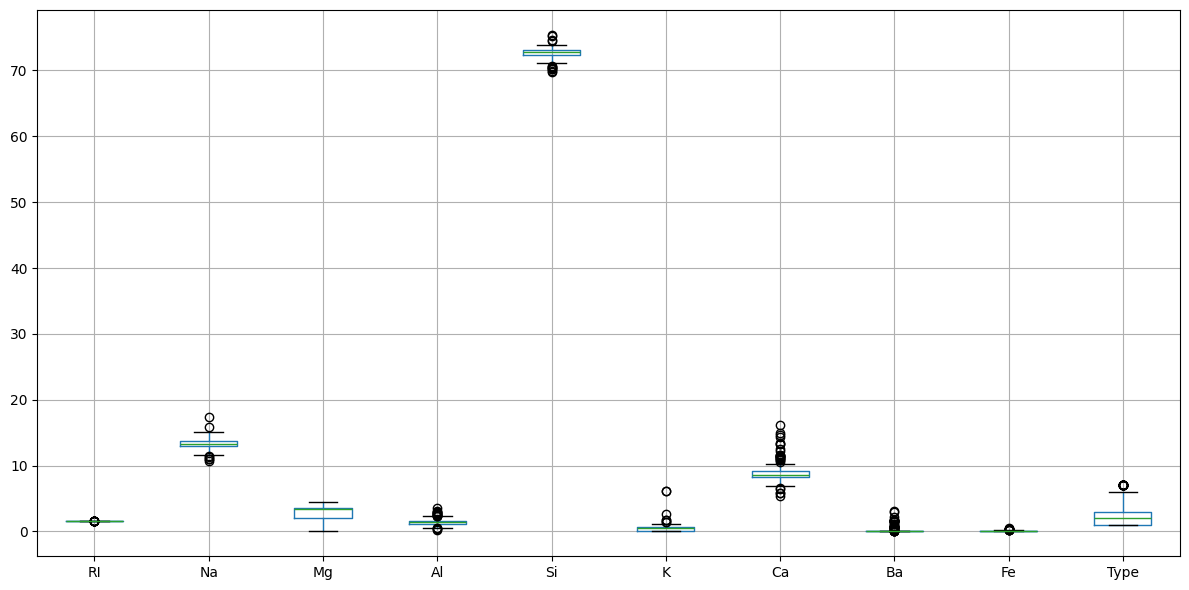

In [29]:
df.boxplot(figsize=(12,6))
plt.tight_layout()
plt.plot()


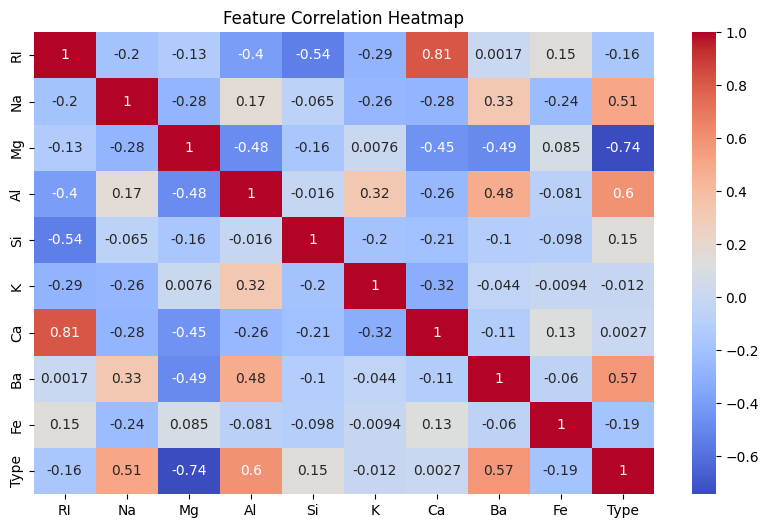

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.


In [31]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [ ]:
# There is no missing value present in the dataset

2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.

  # There is no caterioal column is not present so we can not apply one hot encoding

3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

In [68]:
X = df.drop("Type", axis = 1)
y = df['Type']

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [71]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_scaled, y)


4: Random Forest Model Implementation
1. Divide the data into train and test split.


In [77]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res,test_size=0.2, random_state = 42)

2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.

In [81]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.



In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9456521739130435
Precision: 0.9473128019323671
Recall: 0.9456521739130435
F1 Score: 0.9453762062457713

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.82      0.85        17
           2       0.94      0.89      0.92        19
           3       0.83      1.00      0.91        10
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        18

    accuracy                           0.95        92
   macro avg       0.94      0.95      0.95        92
weighted avg       0.95      0.95      0.95        92



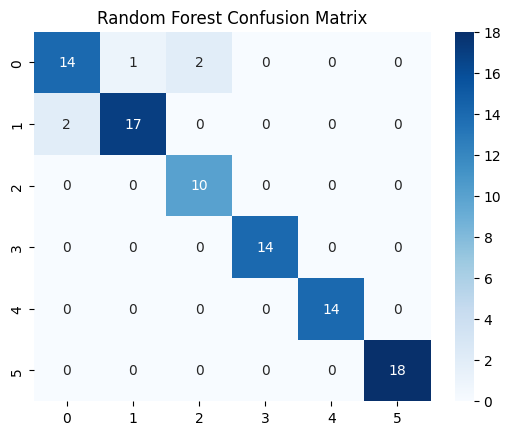

In [83]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

5: Bagging and Boosting Methods

Apply the Bagging and Boosting methods and compare the results.

In [85]:
#bagging technology
bag = BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=10, random_state=42)
bag.fit(X_train, y_train)
y_bag = bag.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, y_bag))

Bagging Accuracy: 0.9456521739130435


In [86]:
# Boosting technology
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_ada = ada.predict(X_test)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_ada))

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_gb = gb.predict(X_test)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_gb))


AdaBoost Accuracy: 0.5652173913043478
Gradient Boosting Accuracy: 0.9239130434782609


1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging (Bootstrap Aggregating):

    Trains multiple models independently on random subsets of data.
    Combines their results (voting/averaging).
    Reduces variance and avoids overfitting.
    Example: Random Forest

Boosting:

    Trains models sequentially, each one correcting errors of the previous.
    Combines all models using weighted voting.
    Reduces bias and variance for higher accuracy.
    Examples: AdaBoost, XGBoost, Gradient Boosting

Bagging = builds many models in parallel to make predictions more stable.
Boosting = builds models in sequence to make predictions more accurate.



In [ ]:
2. Explain how to handle imbalance in the data.

    When one class has much fewer samples than the other (e.g., 90% vs 10%), the model may become biased toward the majority class.
    To fix this, we use the following methods:

    1. Oversampling: Increase minority class samples (e.g., SMOTE).
    2. Undersampling: Reduce majority class samples.
    3. Class Weights: Give more weight to minority class during training.
    4. Use Better Metrics: Use Precision, Recall, F1-score, ROC-AUC instead of Accuracy.
    5. Ensemble Methods: Use models like Balanced Random Forest or XGBoost.